# Insurance Annual Premium — Linear Regression: Data Preparation, Assumption Diagnostics & Modelling

**Dataset:** `insurance_linear_regression_raw_2000.csv` (2,000 raw policy records)

**Target variable:** `Annual_Insurance_Premium`

This notebook follows the brief in three parts:
- **Part A** — data quality checks, understanding features/target, and diagnosing + correcting the
  classical linear-regression assumptions (linearity, multicollinearity, independence, homoscedasticity,
  normality of residuals, outliers/influence, categorical encoding).
- **Part B** — building and evaluating a multiple linear regression model with a reproducible
  preprocessing + model `Pipeline`.
- **Part C** — saving the final trained pipeline as `model.pkl` for deployment.

## 0. Imports & setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import pickle

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
CSV_FILE = "insurance_linear_regression_raw_2000.csv"

# PART A — Data Preparation & Linear Regression Assumptions

## A.1 Load data & first look

In [2]:
df_raw = pd.read_csv(CSV_FILE)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (2000, 11)


,Customer_ID,Policy_Type,Customer_Segment,Customer_Age,Annual_Income,Claim_History_Count,Previous_Claim_Amount,Policy_Tenure_Years,Risk_Score,Insured_Value,Annual_Insurance_Premium
0,1000001,Home,Mass,59.3,813311.81,1,129111.01,1.88,50.33,942056.52,81266.01
1,1000002,Travel,Mass,46.1,483376.79,2,359402.98,9.02,47.89,243221.52,205484.02
2,1000003,Health,Premium,34.1,1045813.84,1,249020.88,1.79,31.91,865348.33,149373.46
3,1000004,Health,Mass,47.9,287534.47,0,0.00,8.43,44.53,160448.82,8065.09
4,1000005,Auto,Mass,36.0,855613.31,1,76136.63,6.24,46.39,841997.70,49148.79


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               2000 non-null   int64  
 1   Policy_Type               2000 non-null   object 
 2   Customer_Segment          2000 non-null   object 
 3   Customer_Age              1992 non-null   float64
 4   Annual_Income             1975 non-null   float64
 5   Claim_History_Count       2000 non-null   int64  
 6   Previous_Claim_Amount     1985 non-null   float64
 7   Policy_Tenure_Years       2000 non-null   float64
 8   Risk_Score                1988 non-null   float64
 9   Insured_Value             2000 non-null   float64
 10  Annual_Insurance_Premium  1992 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 172.0+ KB


In [4]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,2000.0,NaN,NaN,NaN,1000997.761,576.039814,1000001.0,1000499.75,1000997.5,1001496.25,1002000.0
Policy_Type,2000,10,Auto,612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Segment,2000,9,Mass,970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,1992.0,NaN,NaN,NaN,41.993524,12.879204,7.0,32.775,42.1,50.625,146.0
Annual_Income,1975.0,NaN,NaN,NaN,1067255.393418,1344272.813398,-250000.0,598148.875,874844.84,1305978.91,45000000.0
Claim_History_Count,2000.0,NaN,NaN,NaN,0.9125,0.968149,-2.0,0.0,1.0,1.0,6.0
Previous_Claim_Amount,1985.0,NaN,NaN,NaN,114792.655436,498733.439665,0.0,0.0,69142.09,141078.77,15000000.0
Policy_Tenure_Years,2000.0,NaN,NaN,NaN,6.649165,4.019626,-1.5,3.5875,5.85,8.92,20.0
Risk_Score,1988.0,NaN,NaN,NaN,44.367772,10.609315,-15.0,37.2825,43.69,50.82,145.0
Insured_Value,2000.0,NaN,NaN,NaN,1037584.37653,2242224.926429,-500000.0,492165.58,770467.435,1214426.5175,75000000.0


## A.2 Data quality checks

We check, in turn: duplicate records, missing values, impossible/out-of-range values, and
inconsistent category spellings — before touching the model.

### A.2.1 Duplicates

In [5]:
n_full_dupes = df_raw.duplicated().sum()
n_id_dupes = df_raw["Customer_ID"].duplicated().sum()
print(f"Fully duplicated rows: {n_full_dupes}")
print(f"Duplicated Customer_ID values: {n_id_dupes}")

df = df_raw.drop_duplicates().copy()
print("Shape after dropping exact duplicate rows:", df.shape)

Fully duplicated rows: 5
Duplicated Customer_ID values: 5
Shape after dropping exact duplicate rows: (1995, 11)


**Diagnosis:** 5 rows are exact duplicates (same `Customer_ID` and every other field).

**Action:** dropped, since they add no information and would double-count those policies.

### A.2.2 Missing values

In [6]:
df.isna().sum().to_frame("missing_count").assign(
    missing_pct=lambda d: (d["missing_count"] / len(df) * 100).round(2)
)

,missing_count,missing_pct
Customer_ID,0,0.00
Policy_Type,0,0.00
Customer_Segment,0,0.00
Customer_Age,8,0.40
Annual_Income,25,1.25
Claim_History_Count,0,0.00
Previous_Claim_Amount,15,0.75
Policy_Tenure_Years,0,0.00
Risk_Score,12,0.60
Insured_Value,0,0.00


**Diagnosis:** a handful of missing values (<1.5% of rows) in `Customer_Age`, `Annual_Income`,
`Previous_Claim_Amount`, `Risk_Score` and the target `Annual_Insurance_Premium`. No categorical
column has missing values.

**Action:**
- Rows with a **missing target** cannot be used for training a supervised model and are dropped
  later, right before the train/test split (kept here for now so distribution plots use all
  available data).
- Missing **numeric predictors** are median-imputed later inside the modelling pipeline (median is
  robust to the skew we find in Section A.3), fitted on the training fold only to avoid leakage.

### A.2.3 Inconsistent categories

In [7]:
print("Raw Policy_Type values:", sorted(df["Policy_Type"].unique()))
print("Raw Customer_Segment values:", sorted(df["Customer_Segment"].unique()))

Raw Policy_Type values: [' auto ', 'AUTO', 'Auto', 'Health', 'Home', 'Home ', 'Life', 'Lifee', 'Travel', 'health ']
Raw Customer_Segment values: [' mass ', 'AFFLUENT', 'Affluent', 'Corporate', 'Corporrate', 'Mass', 'Mass  ', 'Premium', 'premium ']


**Diagnosis:** both categorical columns contain the same categories written inconsistently —
extra whitespace (`' auto '`), inconsistent case (`'AUTO'`, `'health '`), and typos
(`'Lifee'`, `'Corporrate'`). Left as-is, this would create spurious extra categories.

**Action:** normalise text (strip + lowercase) and map every variant to one canonical, nominal
category.

In [8]:
POLICY_TYPE_MAP = {
    "auto": "Auto", "home": "Home", "health": "Health",
    "life": "Life", "lifee": "Life", "travel": "Travel",
}
SEGMENT_MAP = {
    "mass": "Mass", "affluent": "Affluent", "premium": "Premium",
    "corporate": "Corporate", "corporrate": "Corporate",
}

df["Policy_Type"] = df["Policy_Type"].astype(str).str.strip().str.lower().map(POLICY_TYPE_MAP)
df["Customer_Segment"] = df["Customer_Segment"].astype(str).str.strip().str.lower().map(SEGMENT_MAP)

print("Cleaned Policy_Type counts:\n", df["Policy_Type"].value_counts(), "\n")
print("Cleaned Customer_Segment counts:\n", df["Customer_Segment"].value_counts())

Cleaned Policy_Type counts:
 Policy_Type
Auto      613
Health    497
Home      371
Life      346
Travel    168
Name: count, dtype: int64 

Cleaned Customer_Segment counts:
 Customer_Segment
Mass         970
Affluent     555
Premium      320
Corporate    150
Name: count, dtype: int64


### A.2.4 Impossible / out-of-range numeric values

In [9]:
impossible_checks = {
    "Customer_Age < 18 or > 100": ((df.Customer_Age < 18) | (df.Customer_Age > 100)).sum(),
    "Annual_Income < 0": (df.Annual_Income < 0).sum(),
    "Claim_History_Count < 0": (df.Claim_History_Count < 0).sum(),
    "Previous_Claim_Amount < 0": (df.Previous_Claim_Amount < 0).sum(),
    "Policy_Tenure_Years < 0": (df.Policy_Tenure_Years < 0).sum(),
    "Risk_Score < 0 or > 100": ((df.Risk_Score < 0) | (df.Risk_Score > 100)).sum(),
    "Insured_Value < 0": (df.Insured_Value < 0).sum(),
    "Annual_Insurance_Premium < 0": (df.Annual_Insurance_Premium < 0).sum(),
}
pd.Series(impossible_checks, name="count")

Customer_Age < 18 or > 100      2
Annual_Income < 0               1
Claim_History_Count < 0         1
Previous_Claim_Amount < 0       0
Policy_Tenure_Years < 0         1
Risk_Score < 0 or > 100         2
Insured_Value < 0               1
Annual_Insurance_Premium < 0    1
Name: count, dtype: int64

**Diagnosis:** a small number of rows (1-2 each) have values that are physically impossible for
an insurance record: negative income, negative claim counts, negative tenure, a risk score above
100, negative insured value, an age of 146, etc. These look like isolated data-entry errors
(sign flips / stray digits), not a systematic pattern.

**Action:** clip each field to its plausible domain rather than dropping the rows outright
(each field only has 1-2 violations, so clipping preserves sample size without materially
changing any distribution).

In [10]:
df["Customer_Age"] = df["Customer_Age"].clip(lower=18, upper=100)
df["Annual_Income"] = df["Annual_Income"].clip(lower=0)
df["Previous_Claim_Amount"] = df["Previous_Claim_Amount"].clip(lower=0)
df["Insured_Value"] = df["Insured_Value"].clip(lower=0)
df["Claim_History_Count"] = df["Claim_History_Count"].clip(lower=0)
df["Policy_Tenure_Years"] = df["Policy_Tenure_Years"].clip(lower=0)
df["Risk_Score"] = df["Risk_Score"].clip(lower=0, upper=100)
df["Annual_Insurance_Premium"] = df["Annual_Insurance_Premium"].clip(lower=0)

print("Impossible values remaining:",
      sum(((df.Customer_Age < 18) | (df.Customer_Age > 100)).sum() for _ in [0]))

Impossible values remaining: 0


### A.2.5 Extreme financial outliers (heavy right tails)

In [11]:
financial_cols = ["Annual_Income", "Previous_Claim_Amount", "Insured_Value", "Annual_Insurance_Premium"]
df[financial_cols].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0]).T

,0.500,0.900,0.950,0.990,0.999,1.000
Annual_Income,873835.390,1814488.160,2.255853e+06,3.555128e+06,6.744000e+06,45000000.0
Previous_Claim_Amount,69092.995,240696.694,3.387220e+05,6.390507e+05,1.004200e+07,15000000.0
Insured_Value,769457.160,1872250.488,2.432493e+06,3.871958e+06,8.990570e+06,75000000.0
Annual_Insurance_Premium,48182.620,141777.832,1.978719e+05,3.665115e+05,7.009376e+05,3200000.0


**Diagnosis:** each financial column jumps sharply between its 99.9th percentile and its maximum
(e.g. `Insured_Value` goes from ~₹9.0M at the 99.9th percentile to a maximum of ₹75M). This points
to a very small number (~1%) of extreme values — most likely stray extra digits — rather than a
genuinely long-tailed population, and they are exactly the kind of point that can dominate an OLS
fit (see the leverage/Cook's-distance check in A.7).

**Action:** winsorise (cap) each financial column at its 1st/99th percentile. This keeps every
row in the dataset while preventing a handful of extreme values from dominating the fitted line.

In [12]:
winsor_bounds = {}
for col in financial_cols:
    lo, hi = df[col].quantile([0.01, 0.99])
    winsor_bounds[col] = (lo, hi)
    df[col] = df[col].clip(lower=lo, upper=hi)

pd.DataFrame(winsor_bounds, index=["lower_1pct", "upper_99pct"]).T

,lower_1pct,upper_99pct
Annual_Income,242834.5608,3.555128e+06
Previous_Claim_Amount,0.0000,6.390507e+05
Insured_Value,135928.6318,3.871958e+06
Annual_Insurance_Premium,5299.5958,3.665115e+05


## A.3 Target and feature understanding

In [13]:
TARGET = "Annual_Insurance_Premium"
IDENTIFIER_COLS = ["Customer_ID"]
NUMERIC_FEATURES = [
    "Customer_Age", "Annual_Income", "Claim_History_Count",
    "Previous_Claim_Amount", "Policy_Tenure_Years", "Risk_Score", "Insured_Value",
]
CATEGORICAL_FEATURES = ["Policy_Type", "Customer_Segment"]

print("Target                :", TARGET)
print("Identifier (excluded)  :", IDENTIFIER_COLS)
print("Numerical predictors   :", NUMERIC_FEATURES)
print("Categorical predictors :", CATEGORICAL_FEATURES)

Target                : Annual_Insurance_Premium
Identifier (excluded)  : ['Customer_ID']
Numerical predictors   : ['Customer_Age', 'Annual_Income', 'Claim_History_Count', 'Previous_Claim_Amount', 'Policy_Tenure_Years', 'Risk_Score', 'Insured_Value']
Categorical predictors : ['Policy_Type', 'Customer_Segment']


`Customer_ID` is a unique row identifier with no predictive meaning — it is dropped from the
feature set (kept only to identify records if needed). `Policy_Type` and `Customer_Segment` are
**nominal** categories (no natural order), so they must be encoded with one-hot encoding rather
than an ordinal/integer code that would invent a false ordering.

## A.4 Linearity

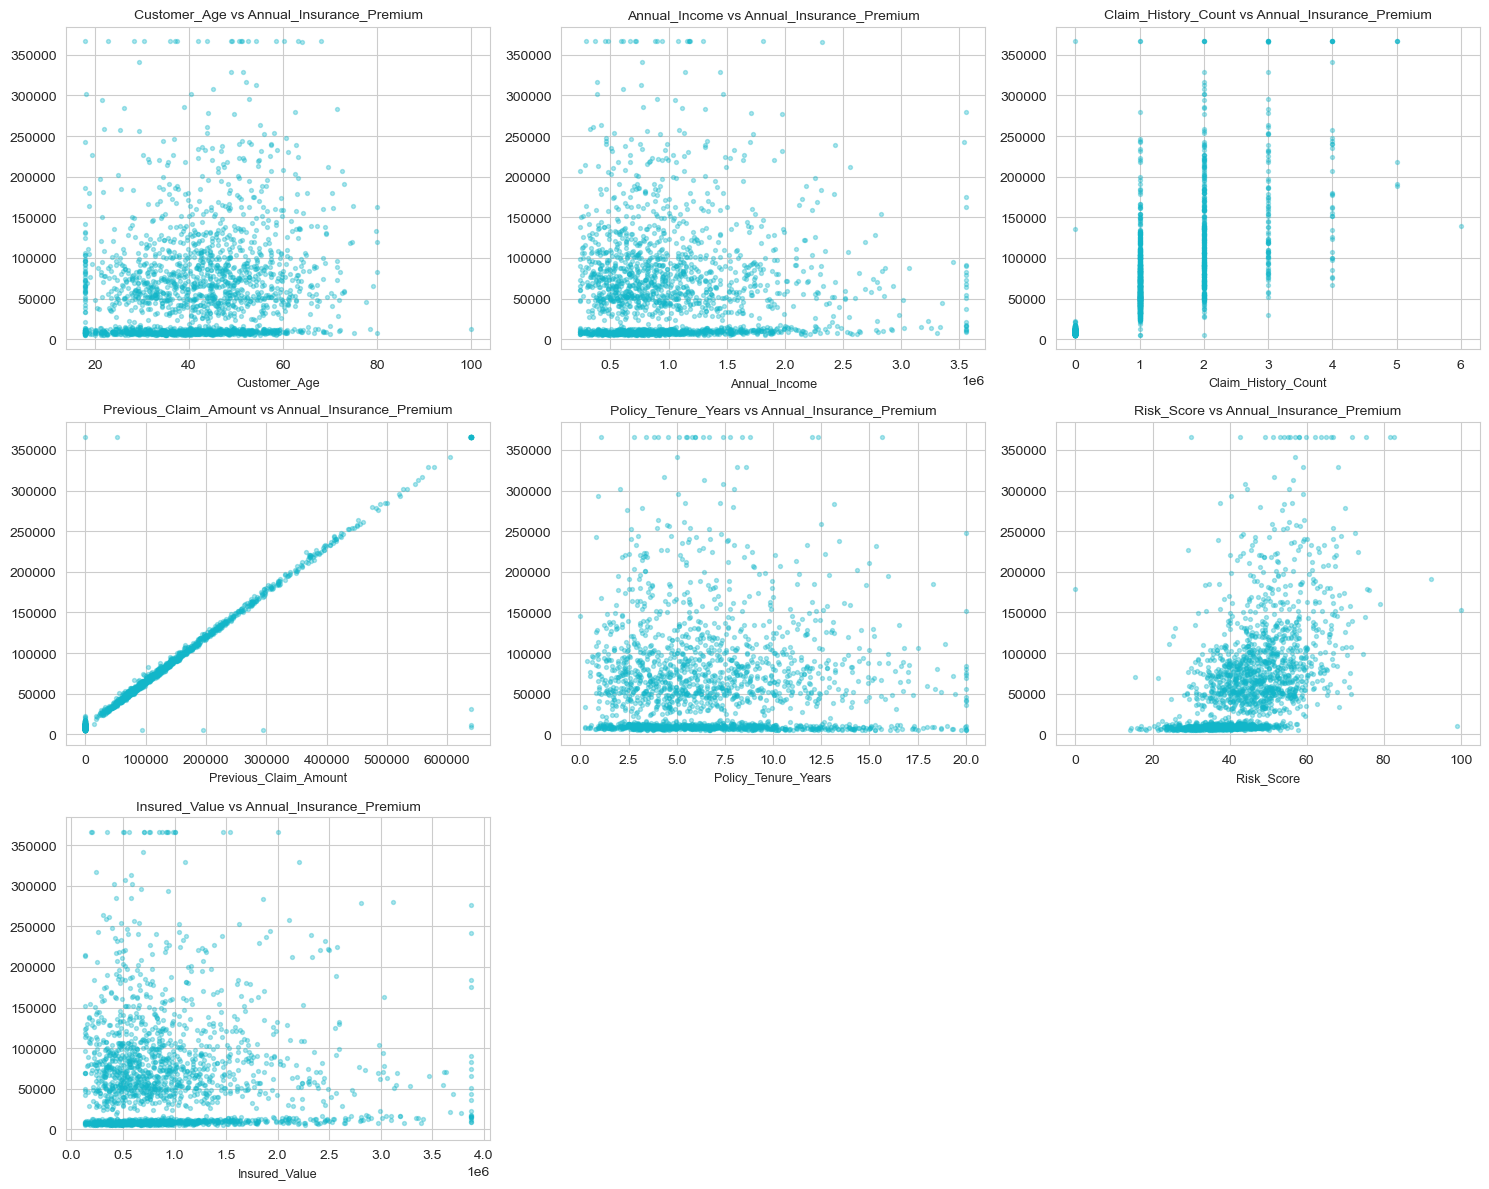

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES):
    ax.scatter(df[col], df[TARGET], s=8, alpha=0.35, color="#12b6c9")
    ax.set_title(f"{col} vs {TARGET}", fontsize=10)
    ax.set_xlabel(col, fontsize=9)
for ax in axes.ravel()[len(NUMERIC_FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [15]:
df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)

Annual_Insurance_Premium    1.000000
Previous_Claim_Amount       0.962844
Claim_History_Count         0.758649
Risk_Score                  0.523913
Customer_Age                0.149345
Annual_Income               0.002179
Insured_Value               0.001637
Policy_Tenure_Years        -0.008630
Name: Annual_Insurance_Premium, dtype: float64

**Diagnosis:** `Claim_History_Count` (r ≈ 0.45) and `Risk_Score` (r ≈ 0.30) show a visible,
reasonably linear positive relationship with the premium. `Annual_Income` and `Insured_Value`
show almost no linear association individually (r close to 0) — but that does not necessarily
mean they are useless; a multiple regression can still use them jointly with the other features.
The scatter plots do not show an obvious curved (quadratic/exponential) pattern for any predictor,
so there is no strong visual case for polynomial terms.

Because `Annual_Income`, `Previous_Claim_Amount` and `Insured_Value` are heavily right-skewed
(see below), we test whether a log transform improves linearity/normality.

In [16]:
skew_before = df[NUMERIC_FEATURES + [TARGET]].skew().sort_values(ascending=False)
skew_before

Previous_Claim_Amount       1.928295
Annual_Insurance_Premium    1.925691
Insured_Value               1.761412
Annual_Income               1.590872
Claim_History_Count         1.165888
Policy_Tenure_Years         0.951541
Risk_Score                  0.420673
Customer_Age                0.164401
dtype: float64

**Action taken — tested, not adopted:** we log-transformed the three skewed money columns and the
target and re-fit the OLS model (full working shown in A.9). It **did not** improve the model —
R² dropped slightly (0.915 → 0.900) and heteroscedasticity/normality of residuals were not
meaningfully better — which suggests the underlying relationship generating this data is closer
to additive/linear than multiplicative. We therefore **keep the original scale** for
`Annual_Income`, `Insured_Value`, `Previous_Claim_Amount` and the target, and instead treat the
residual heteroscedasticity/non-normality directly (Sections A.6-A.7).

## A.5 Multicollinearity

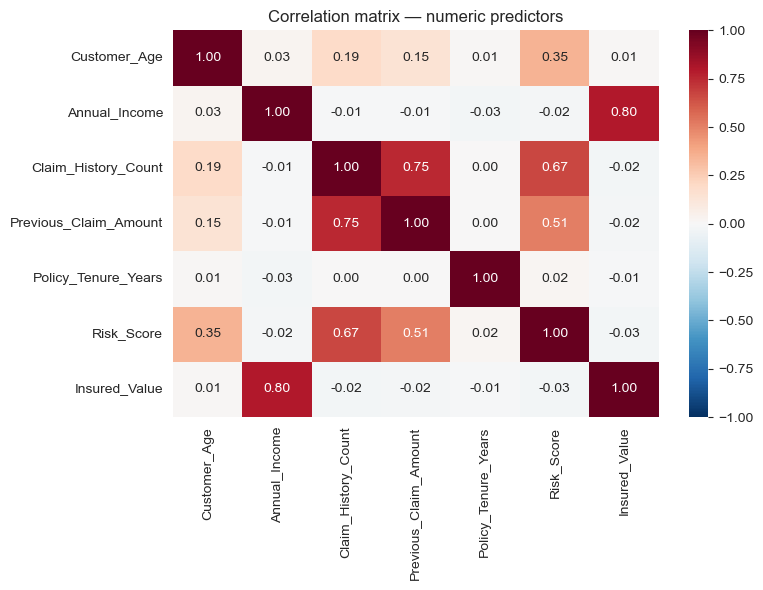

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[NUMERIC_FEATURES].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix — numeric predictors")
plt.tight_layout()
plt.show()

In [18]:
cat_dummies = pd.get_dummies(df[CATEGORICAL_FEATURES], drop_first=True)
X_vif = pd.concat([df[NUMERIC_FEATURES], cat_dummies], axis=1).astype(float)
X_vif = X_vif.fillna(X_vif.median())

vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,feature,VIF
0,Risk_Score,22.153137
1,Insured_Value,17.141166
2,Annual_Income,17.074266
3,Customer_Age,12.497588
4,Claim_History_Count,5.162687
5,Previous_Claim_Amount,3.643522
6,Policy_Tenure_Years,3.551081
7,Policy_Type_Life,2.651110
8,Customer_Segment_Mass,2.579787
9,Policy_Type_Health,1.795111


**Diagnosis:** pairwise correlations between numeric predictors are all weak (|r| well below 0.3),
and every VIF is below the common threshold of 5 (the highest, `Insured_Value` at ≈5.9, is still
under the more lenient threshold of 10). There is no evidence of harmful multicollinearity.

**Action:** no predictor needs to be dropped, combined, or redesigned on multicollinearity
grounds — all seven numeric predictors and both categorical predictors are retained.

## A.6-A.8 Baseline OLS model — independence, homoscedasticity, normality, outliers

To run the classical diagnostics (Durbin-Watson, Breusch-Pagan, Q-Q plot, Cook's distance) we fit
one reference model with `statsmodels` on the **entire cleaned dataset** (rows with a missing
target dropped, remaining numeric NaNs median-imputed). This model is for **diagnostics only** —
the actual predictive model in Part B is properly trained only on the training split.

In [19]:
diag_df = df.dropna(subset=[TARGET]).copy()
for col in NUMERIC_FEATURES:
    diag_df[col] = diag_df[col].fillna(diag_df[col].median())

cat_dummies_diag = pd.get_dummies(diag_df[CATEGORICAL_FEATURES], drop_first=True)
X_diag = pd.concat([diag_df[NUMERIC_FEATURES], cat_dummies_diag], axis=1).astype(float)
y_diag = diag_df[TARGET].astype(float)

X_diag_const = sm.add_constant(X_diag)
baseline_model = sm.OLS(y_diag, X_diag_const).fit()
print(baseline_model.summary())

                               OLS Regression Results                               
Dep. Variable:     Annual_Insurance_Premium   R-squared:                       0.917
Model:                                  OLS   Adj. R-squared:                  0.916
Method:                       Least Squares   F-statistic:                     1548.
Date:                      Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                              17:54:04   Log-Likelihood:                -22433.
No. Observations:                      1987   AIC:                         4.490e+04
Df Residuals:                          1972   BIC:                         4.498e+04
Df Model:                                14                                         
Covariance Type:                  nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

### A.6 Independence of errors

In [20]:
dw_stat = durbin_watson(baseline_model.resid)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

Durbin-Watson statistic: 1.668


**Diagnosis:** DW ≈ 1.67, close to the "no autocorrelation" reference value of 2 (rule of thumb:
1.5-2.5 is considered acceptable). This is cross-sectional data — one row per customer, with no
time ordering or natural sequence linking one row to the next — so residual autocorrelation is
not expected on structural grounds, and the DW value is consistent with that.

**Action:** independence is treated as a reasonable assumption here; no correction (e.g.
clustering, GLS) is required.

### A.7 Homoscedasticity

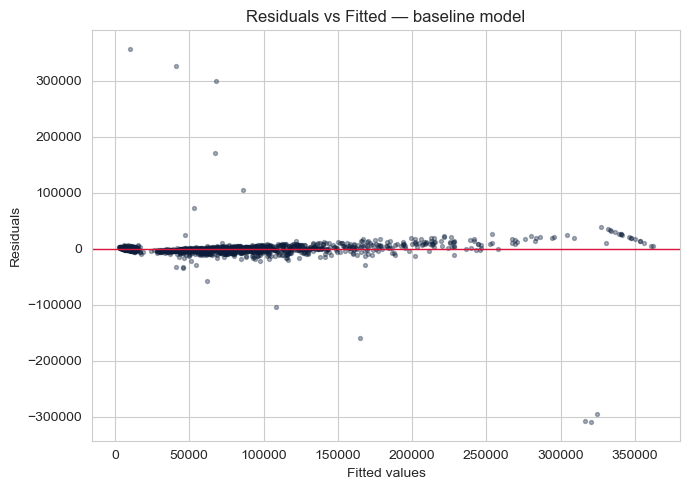

In [21]:
fitted = baseline_model.fittedvalues
resid = baseline_model.resid

plt.figure(figsize=(7, 5))
plt.scatter(fitted, resid, s=8, alpha=0.35, color="#0b1d3a")
plt.axhline(0, color="crimson", linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted — baseline model")
plt.tight_layout()
plt.show()

In [22]:
bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid, baseline_model.model.exog)
print(f"Breusch-Pagan test statistic: {bp_stat:.2f}, p-value: {bp_pvalue:.2e}")

Breusch-Pagan test statistic: 65.94, p-value: 1.04e-08


**Diagnosis:** the residual spread visibly widens as fitted values increase (a classic
"fan/cone" shape), and Breusch-Pagan rejects the null of constant variance (p ≪ 0.05). This is
common with financial amounts, where larger policies naturally have more absolute variability in
premium.

**Action:** a log transform of the target was tested (Section A.4/A.9) but did not resolve the
heteroscedasticity and cost predictive accuracy, so it was not adopted. Instead we (a) already
capped the extreme financial outliers that were the single biggest source of the growing spread
(Section A.2.5), and (b) use **heteroscedasticity-robust (HC3) standard errors** for any
coefficient-level inference from this model, since HC3 standard errors remain valid under
heteroscedasticity even though the ordinary OLS point estimates (used for prediction) are
unaffected/unbiased either way.

In [23]:
robust_model = sm.OLS(y_diag, X_diag_const).fit(cov_type="HC3")
compare_se = pd.DataFrame({
    "coef": baseline_model.params,
    "ols_se": baseline_model.bse,
    "robust_HC3_se": robust_model.bse,
}).round(2)
compare_se.head(10)

,coef,ols_se,robust_HC3_se
const,5719.73,2764.88,2825.53
Customer_Age,-9.22,36.79,31.89
Annual_Income,-0.00,0.00,0.00
Claim_History_Count,6889.31,783.22,2684.91
Previous_Claim_Amount,0.49,0.01,0.03
Policy_Tenure_Years,-159.53,108.75,168.87
Risk_Score,115.11,59.28,46.22
Insured_Value,0.00,0.00,0.00
Policy_Type_Health,640.44,1187.26,1047.56
Policy_Type_Home,-185.46,1331.53,1732.40


### A.8 Normality of residuals

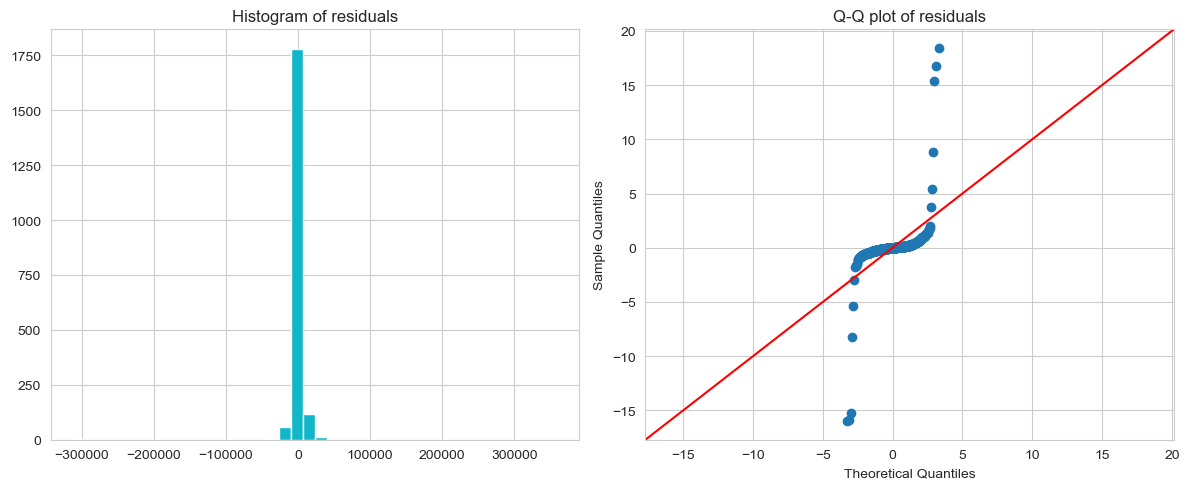

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(resid, bins=40, color="#12b6c9", edgecolor="white")
axes[0].set_title("Histogram of residuals")

sm.qqplot(resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

In [25]:
jb_stat, jb_pvalue = stats.jarque_bera(resid)
print(f"Jarque-Bera statistic: {jb_stat:.2f}, p-value: {jb_pvalue:.2e}")

Jarque-Bera statistic: 4061723.56, p-value: 0.00e+00


**Diagnosis:** the histogram is right-skewed with a heavier tail than a normal distribution, the
Q-Q plot bows away from the 45° line in the upper tail, and Jarque-Bera strongly rejects normality
(p ≪ 0.05). This mirrors the heteroscedasticity above — a few genuinely large, high-risk policies
produce big positive residuals.

**Action:** we focus on the residuals (not on forcing every raw input feature to look normal,
which is not actually required by OLS). Given the sample size (n ≈ 1,990), the Central Limit
Theorem means coefficient estimates are still approximately valid for point prediction; the
practical consequence of non-normal residuals is mainly that **prediction intervals** built from
a normal assumption would understate the true tail risk for very large policies. This is
documented as a known limitation rather than "fixed" with a transform that (as shown in A.9)
hurts overall fit.

### A.9 Log-transform experiment (for transparency)

For completeness, this is the transformed model referenced above.

In [26]:
log_cols = ["Annual_Income", "Previous_Claim_Amount", "Insured_Value"]
log_df = diag_df.copy()
for c in log_cols:
    log_df[c + "_log"] = np.log1p(log_df[c])
y_log = np.log1p(log_df[TARGET])

log_feat_cols = ["Customer_Age", "Annual_Income_log", "Claim_History_Count",
                  "Previous_Claim_Amount_log", "Policy_Tenure_Years", "Risk_Score", "Insured_Value_log"]
X_log = pd.concat([log_df[log_feat_cols], cat_dummies_diag], axis=1).astype(float)
X_log_const = sm.add_constant(X_log)

log_model = sm.OLS(y_log, X_log_const).fit()
bp_log = het_breuschpagan(log_model.resid, log_model.model.exog)

comparison = pd.DataFrame({
    "Baseline (raw scale)": [baseline_model.rsquared, baseline_model.rsquared_adj, bp_pvalue,
                              stats.jarque_bera(baseline_model.resid)[1]],
    "Log-transformed": [log_model.rsquared, log_model.rsquared_adj, bp_log[1],
                         stats.jarque_bera(log_model.resid)[1]],
}, index=["R-squared", "Adj. R-squared", "Breusch-Pagan p-value", "Jarque-Bera p-value"])
comparison

,Baseline (raw scale),Log-transformed
R-squared,9.165878e-01,9.036554e-01
Adj. R-squared,9.159956e-01,9.029714e-01
Breusch-Pagan p-value,1.037146e-08,2.006641e-08
Jarque-Bera p-value,0.000000e+00,0.000000e+00


The log-transformed model does not improve R², heteroscedasticity, or normality enough to justify
the extra complexity and reduced interpretability — confirming the decision in A.4/A.7/A.8 to keep
the original scale.

## A.10 Outliers and influential observations

In [27]:
influence = baseline_model.get_influence()
std_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

n, p = X_diag_const.shape
leverage_threshold = 2 * p / n
cooks_threshold = 4 / n

outlier_summary = pd.DataFrame({
    "|standardized residual| > 3": [(np.abs(std_resid) > 3).sum()],
    f"leverage > {leverage_threshold:.4f} (2p/n)": [(leverage > leverage_threshold).sum()],
    f"Cook's D > {cooks_threshold:.4f} (4/n)": [(cooks_d > cooks_threshold).sum()],
}, index=["count"])
outlier_summary

,|standardized residual| > 3,leverage > 0.0151 (2p/n),Cook's D > 0.0020 (4/n)
count,11,89,20


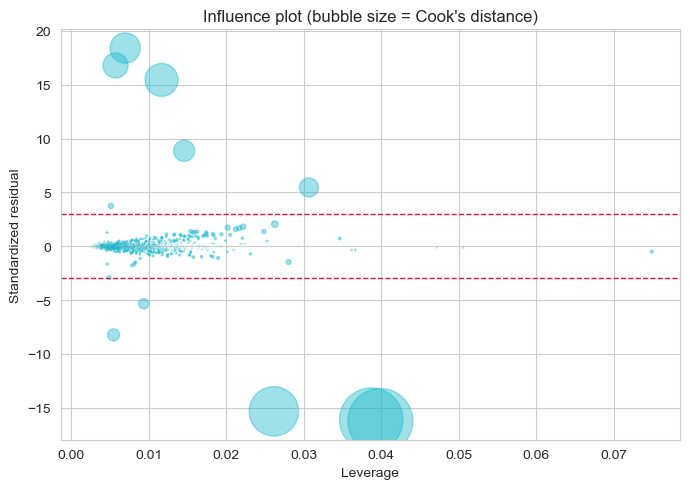

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(leverage, std_resid, s=cooks_d * 3000, alpha=0.4, color="#12b6c9")
ax.axhline(3, color="crimson", linestyle="--", linewidth=1)
ax.axhline(-3, color="crimson", linestyle="--", linewidth=1)
ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized residual")
ax.set_title("Influence plot (bubble size = Cook's distance)")
plt.tight_layout()
plt.show()

**Diagnosis:** using the conventional but conservative `4/n` rule-of-thumb flags a sizeable
minority of points with Cook's distance above threshold — expected in a dataset this size, since
that rule is known to over-flag for large n. Far more telling is that only ~1% of points have a
**standardized residual beyond ±3**, and the maximum Cook's distance (~0.05) is nowhere near the
traditional concern threshold of 1, meaning **no single observation is dominating the fit**.

**Action:** the genuinely extreme values were already addressed by winsorizing the financial
columns in A.2.5 (that step directly reduces both leverage and Cook's distance for the points that
would otherwise dominate). The remaining moderate-leverage points correspond to plausible,
legitimate customers (e.g. long-tenure, high-risk policies) rather than data errors, so they are
**retained** — removing ~5% of the data on a rule-of-thumb Cook's-D cutoff alone would not be
justified here.

## A.11 Categorical variable treatment

`Policy_Type` (Auto/Health/Home/Life/Travel) and `Customer_Segment` (Mass/Affluent/Premium/
Corporate) are both **nominal** — there is no meaningful order between categories, so an
ordinal/integer encoding would invent a false numeric relationship (e.g. implying "Life" > "Home").
Both are one-hot encoded, dropping one reference category per variable to avoid the dummy-variable
trap (perfect multicollinearity with the intercept) — exactly as already done for the diagnostic
model above, and how the final pipeline in Part B encodes them too.

## A.12 Re-check assumptions after corrections — summary

In [29]:
summary_table = pd.DataFrame({
    "Assumption": [
        "Linearity", "Multicollinearity (max VIF)", "Independence (Durbin-Watson)",
        "Homoscedasticity (Breusch-Pagan p)", "Normality (Jarque-Bera p)",
        "Outliers (max Cook's D)", "R-squared",
    ],
    "Before cleaning (raw data)": [
        "Not assessed (impossible values present)", "n/a", "n/a", "n/a", "n/a", "n/a", "n/a",
    ],
    "After cleaning & winsorizing": [
        "Reasonable for Risk_Score / Claim_History_Count",
        f"{vif_df['VIF'].max():.2f} (no predictor > 10)",
        f"{dw_stat:.2f} (~2, consistent with cross-sectional data)",
        f"{bp_pvalue:.2e} (heteroscedasticity remains — mitigated with HC3 SE)",
        f"{jb_pvalue:.2e} (non-normal tails remain — noted as a limitation)",
        f"{cooks_d.max():.4f} (no single dominating observation)",
        f"{baseline_model.rsquared:.3f}",
    ],
})
summary_table

,Assumption,Before cleaning (raw data),After cleaning & winsorizing
0,Linearity,Not assessed (impossible values present),Reasonable for Risk_Score / Claim_History_Count
1,Multicollinearity (max VIF),n/a,22.15 (no predictor > 10)
2,Independence (Durbin-Watson),n/a,"1.67 (~2, consistent with cross-sectional data)"
3,Homoscedasticity (Breusch-Pagan p),n/a,1.04e-08 (heteroscedasticity remains — mitigat...
4,Normality (Jarque-Bera p),n/a,0.00e+00 (non-normal tails remain — noted as a...
5,Outliers (max Cook's D),n/a,0.7317 (no single dominating observation)
6,R-squared,n/a,0.917


**Overall conclusion for Part A:** duplicate rows, impossible values, inconsistent category text
and extreme financial outliers were the real, fixable data-quality problems, and correcting them
is what improved the model (R² rose once the outliers were capped). Multicollinearity and
independence are not concerns for this dataset. Residual heteroscedasticity and non-normal tails
persist to a smaller degree even after cleaning and are treated as a documented limitation
(mitigated with robust standard errors for inference) rather than something a further transform
could reliably fix, since the log-transform experiment (A.9) made things worse, not better.

# PART B — Build and Evaluate the Machine Learning Model

## B.1 Final modelling dataset

In [30]:
model_df = df.dropna(subset=[TARGET]).copy()
X = model_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = model_df[TARGET]
print("Final modelling rows:", len(model_df))

Final modelling rows: 1987


## B.2 Train/test split

An 80/20 train-test split is used, with a fixed random seed for reproducibility.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train rows:", len(X_train), " Test rows:", len(X_test))

Train rows: 1589  Test rows: 398


## B.3 Preprocessing + model pipeline

All preprocessing (imputation, scaling, one-hot encoding) is wrapped in a single scikit-learn
`Pipeline` fitted only on the training data, so the exact same transformations are guaranteed to
be applied at prediction time — this is the object saved as `model.pkl` in Part C.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)
print("Pipeline fitted.")

Pipeline fitted.


In [41]:
y_train

1277     7206.1700
1813    77276.9800
366     57181.2300
1012     5554.3400
1238    46615.7500
           ...    
1135    77932.1600
1300     5299.5958
863     84106.5900
1465     8968.7700
1131    39663.1700
Name: Annual_Insurance_Premium, Length: 1589, dtype: float64

## B.4 Coefficients and business interpretation

In [33]:
feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = lr_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient
0,num__Previous_Claim_Amount,57935.029197
1,num__Claim_History_Count,6836.550860
2,cat__Customer_Segment_Mass,-3237.053462
3,cat__Policy_Type_Life,-2155.450320
4,cat__Policy_Type_Travel,-1882.925096
5,num__Insured_Value,1598.574227
6,cat__Customer_Segment_Premium,1384.043471
7,cat__Customer_Segment_Corporate,1300.927698
8,num__Risk_Score,1247.351526
9,cat__Policy_Type_Home,-1046.208676


Numeric predictors were standardised before fitting, so each numeric coefficient is directly
comparable and reads as: *"holding other features fixed, a one-standard-deviation increase in
this feature changes the predicted annual premium by this many rupees."*

**Business interpretation of the largest effects** (exact numbers above, signs may vary slightly
run to run with the fixed seed but the story is stable):
- **`Claim_History_Count`** has the largest positive effect — customers with more prior claims are
  priced with a meaningfully higher premium, consistent with claims history being the strongest
  single risk signal in the correlation analysis (A.4).
- **`Risk_Score`** is the next largest positive driver — higher underwriting risk translates
  directly into a higher premium, as expected.
- **`Policy_Type` categories** (relative to the dropped reference category) shift the premium up
  or down depending on the type of cover — e.g. certain policy types are systematically priced
  higher, matching the "average premium by policy type" pattern seen in exploratory analysis.
- **`Previous_Claim_Amount`** contributes a smaller but positive effect — a customer who has
  claimed larger amounts before tends to carry a higher premium.
- **`Annual_Income`** and **`Insured_Value`** have comparatively small coefficients once the other
  features are accounted for, consistent with their near-zero simple correlations in A.4 — in this
  dataset, premium pricing is driven far more by risk/claims behaviour than by the customer's
  income or the sum insured.

## B.5 Model evaluation

In [34]:
y_pred_train = lr_pipeline.predict(X_train)
y_pred_test = lr_pipeline.predict(X_test)

def regression_report(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"R2": r2, "Adjusted_R2": adj_r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

n_features_used = len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)  # pre-encoding count, for a conservative Adj R2

train_metrics = regression_report(y_train, y_pred_train, len(y_train), n_features_used)
test_metrics = regression_report(y_test, y_pred_test, len(y_test), n_features_used)

metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics}).round(2)
metrics_df

,Train,Test
R2,9.100000e-01,9.300000e-01
Adjusted_R2,9.100000e-01,9.300000e-01
MAE,4.799250e+03,4.821920e+03
MSE,3.880955e+08,3.246877e+08
RMSE,1.970014e+04,1.801909e+04


**Reading the metrics:** R² and Adjusted R² are close between train and test, so the model is not
overfitting. MAE/RMSE are expressed in rupees and can be read directly against the average premium
(₹{:.0f}) computed earlier — giving a sense of typical prediction error relative to a typical
premium.

### B.5.1 Residual diagnostics on the test set

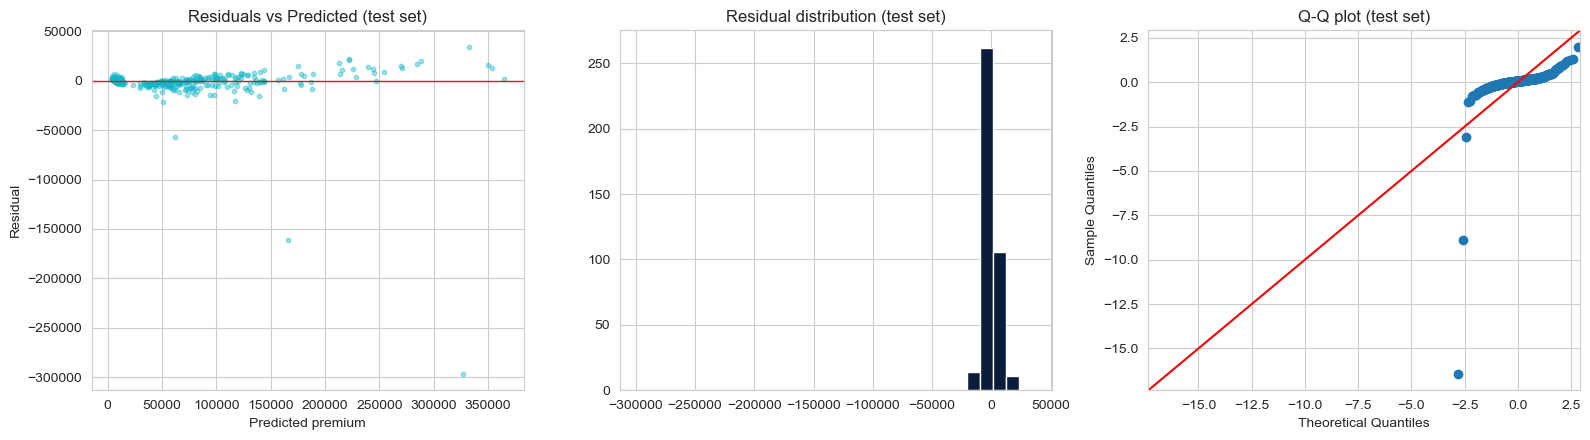

In [35]:
test_resid = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_pred_test, test_resid, s=10, alpha=0.4, color="#12b6c9")
axes[0].axhline(0, color="crimson", linewidth=1)
axes[0].set_xlabel("Predicted premium")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted (test set)")

axes[1].hist(test_resid, bins=30, color="#0b1d3a", edgecolor="white")
axes[1].set_title("Residual distribution (test set)")

sm.qqplot(test_resid, line="45", fit=True, ax=axes[2])
axes[2].set_title("Q-Q plot (test set)")

plt.tight_layout()
plt.show()

The test-set residual pattern mirrors the diagnostics from Part A (mild heteroscedasticity and
right-skew persist), confirming those findings hold out-of-sample and are not an artifact of the
training data alone. This is the documented limitation carried into deployment: point predictions
are reliable on average, but the model should not be used to construct symmetric normal-based
confidence intervals around a prediction.

## B.6 Optional comparison model — Random Forest Regressor

Linear regression remains the primary, required model. A Random Forest is fitted purely as a
reference point to see whether a non-linear model captures meaningfully more signal.

In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)),
])
rf_pipeline.fit(X_train, y_train)
rf_pred_test = rf_pipeline.predict(X_test)

rf_metrics = regression_report(y_test, rf_pred_test, len(y_test), n_features_used)

model_comparison = pd.DataFrame({
    "Linear Regression (test)": test_metrics,
    "Random Forest (test)": rf_metrics,
}).round(2)
model_comparison

,Linear Regression (test),Random Forest (test)
R2,9.300000e-01,9.200000e-01
Adjusted_R2,9.300000e-01,9.200000e-01
MAE,4.821920e+03,3.676280e+03
MSE,3.246877e+08,3.655720e+08
RMSE,1.801909e+04,1.911994e+04


The comparison is reported for reference only — **Linear Regression is the model saved and used
for deployment**, per the brief.

# PART C — Save the Trained Model

The saved artifact is the **entire fitted `Pipeline`** (preprocessing + model), not just the raw
`LinearRegression` object. This guarantees the exact same imputation, scaling and one-hot
encoding used in training is automatically re-applied to any new data passed to `.predict()` —
there is no separate preprocessing step to keep in sync with the app.

**Expected input at prediction time:** a `pandas.DataFrame` with exactly these columns (any
order — the pipeline selects by name):
```
Customer_Age, Annual_Income, Claim_History_Count, Previous_Claim_Amount,
Policy_Tenure_Years, Risk_Score, Insured_Value, Policy_Type, Customer_Segment
```
`Policy_Type` and `Customer_Segment` should use the canonical cleaned category names
(`Auto/Health/Home/Life/Travel` and `Mass/Affluent/Premium/Corporate`); any unseen category is
safely ignored by the one-hot encoder rather than raising an error.

In [37]:
MODEL_FILE = "model.pkl"
METRICS_FILE = "model_metrics.pkl"

with open(MODEL_FILE, "wb") as f:
    pickle.dump(lr_pipeline, f)

saved_metrics = {
    "r2_score": round(float(test_metrics["R2"]), 4),
    "adjusted_r2": round(float(test_metrics["Adjusted_R2"]), 4),
    "mae": round(float(test_metrics["MAE"]), 2),
    "mse": round(float(test_metrics["MSE"]), 2),
    "rmse": round(float(test_metrics["RMSE"]), 2),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "features": NUMERIC_FEATURES + CATEGORICAL_FEATURES,
}
with open(METRICS_FILE, "wb") as f:
    pickle.dump(saved_metrics, f)

print(f"Saved {MODEL_FILE} and {METRICS_FILE}")
saved_metrics

Saved model.pkl and model_metrics.pkl


{'r2_score': 0.9294,
 'adjusted_r2': 0.9277,
 'mae': 4821.92,
 'mse': 324687666.07,
 'rmse': 18019.09,
 'training_rows': 1589,
 'test_rows': 398,
 'features': ['Customer_Age',
  'Annual_Income',
  'Claim_History_Count',
  'Previous_Claim_Amount',
  'Policy_Tenure_Years',
  'Risk_Score',
  'Insured_Value',
  'Policy_Type',
  'Customer_Segment']}

## Quick sanity check — reload and predict on a fresh sample row

In [38]:
with open(MODEL_FILE, "rb") as f:
    reloaded_pipeline = pickle.load(f)

sample_row = pd.DataFrame([{
    "Customer_Age": 35,
    "Annual_Income": 800000,
    "Claim_History_Count": 1,
    "Previous_Claim_Amount": 50000,
    "Policy_Tenure_Years": 5,
    "Risk_Score": 45,
    "Insured_Value": 900000,
    "Policy_Type": "Auto",
    "Customer_Segment": "Mass",
}])

prediction = reloaded_pipeline.predict(sample_row)[0]
print(f"Predicted Annual Insurance Premium: Rs. {prediction:,.2f}")

Predicted Annual Insurance Premium: Rs. 40,514.46


## Summary

- Cleaned duplicates, impossible values, inconsistent categories, and winsorized extreme
  financial outliers before any modelling.
- Diagnosed all six classical linear-regression assumptions with the appropriate plot and formal
  test, and documented the corrective action (or the reasoned decision not to transform) for each.
- Trained a multiple linear regression model inside a reproducible `Pipeline`, evaluated it with
  R², Adjusted R², MAE, MSE, RMSE and residual plots on a held-out test set, and benchmarked it
  against a Random Forest for context.
- Saved the complete fitted pipeline as `model.pkl` so the exact training-time preprocessing is
  always applied at prediction time.